In [1]:
# Topic Modelling, Keyword Frequency & Co-occurrence

import json
import warnings
from collections import Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from wordcloud import WordCloud

warnings.filterwarnings("ignore", category=DeprecationWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR  = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR  = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
BRAND_COLORS = {"Wired": "#1A1A1A", "The Verge": "#FA4B2A"}

wired_posts = pd.read_csv(PROC_DIR / "wired_posts_sentiment.csv")
verge_posts = pd.read_csv(PROC_DIR / "verge_posts_sentiment.csv")

# Replace any NaN cleaned-text with empty string (downstream code expects str)
for df in (wired_posts, verge_posts):
    df["text_clean"]          = df["text_clean"].fillna("").astype(str)
    df["text_clean_no_brand"] = df["text_clean_no_brand"].fillna("").astype(str)

print(f"Loaded {len(wired_posts)} Wired and {len(verge_posts)} Verge posts.")

Loaded 1578 Wired and 1153 Verge posts.


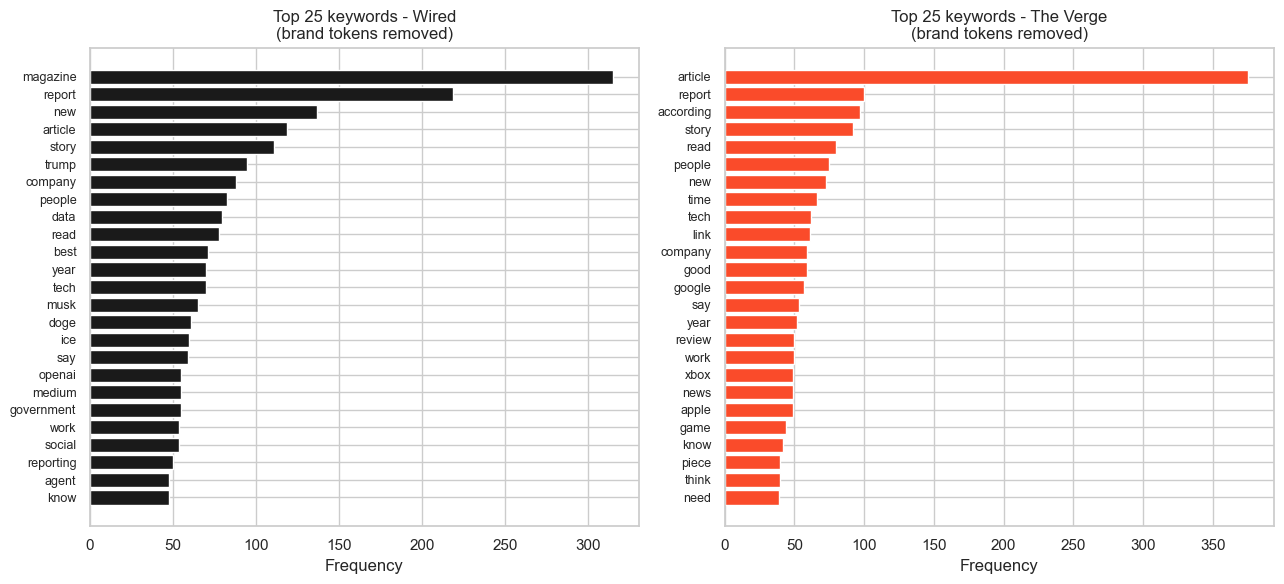

Distinctive to Wired (count_wired, count_verge):
  magazine            315 vs    0
  report              219 vs  100
  new                 137 vs   73
  doge                 61 vs    0
  trump                95 vs   35
  ice                  60 vs    0
  government           55 vs    0
  data                 80 vs   29
  reporting            50 vs    0
  best                 71 vs   22
  agent                48 vs    0
  anthropic            45 vs    0
  elon                 45 vs    0
  code                 44 vs    0
  security             43 vs    0

Distinctive to Verge (count_verge, count_wired):
  article             375 vs  119
  according            97 vs    0
  link                 61 vs    0
  xbox                 49 vs    0
  game                 44 vs    0
  need                 39 vs    0
  love                 33 vs    0
  microsoft            32 vs    0
  podcast              32 vs    0
  every                32 vs    0
  search               31 vs    0
  next           

In [2]:
def top_keywords(df: pd.DataFrame, col: str = "text_clean_no_brand", n: int = 25) -> list[tuple[str, int]]:
    counter = Counter()
    for txt in df[col]:
        if txt:
            counter.update(txt.split())
    return counter.most_common(n)

wired_kw = top_keywords(wired_posts)
verge_kw = top_keywords(verge_posts)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (brand, kws) in zip(axes, [("Wired", wired_kw), ("The Verge", verge_kw)]):
    labels, counts = zip(*kws)
    ax.barh(range(len(labels)), counts, color=BRAND_COLORS[brand])
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"Top 25 keywords - {brand}\n(brand tokens removed)")
    ax.set_xlabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_top_keywords.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(wired_kw, columns=["keyword", "count"]).to_csv(TAB_DIR / "08_wired_top_keywords.csv", index=False)
pd.DataFrame(verge_kw, columns=["keyword", "count"]).to_csv(TAB_DIR / "08_verge_top_keywords.csv", index=False)

# Distinctive keywords: what does Wired talk about that Verge doesn't, and vice versa?
wired_set, verge_set = dict(top_keywords(wired_posts, n=80)), dict(top_keywords(verge_posts, n=80))
distinctive_wired = sorted(
    [(k, v, verge_set.get(k, 0)) for k, v in wired_set.items()],
    key=lambda x: x[1] - x[2], reverse=True
)[:15]
distinctive_verge = sorted(
    [(k, verge_set.get(k, 0), wired_set.get(k, 0)) for k in verge_set],
    key=lambda x: x[1] - x[2], reverse=True
)[:15]
print("Distinctive to Wired (count_wired, count_verge):")
for k, w, v in distinctive_wired: print(f"  {k:<18} {w:>4} vs {v:>4}")
print("\nDistinctive to Verge (count_verge, count_wired):")
for k, v, w in distinctive_verge: print(f"  {k:<18} {v:>4} vs {w:>4}")

In [3]:
# Tokenise the brand-stripped cleaned text. Filter rare tokens (< 5 docs) and very common tokens (> 60% of docs) to focus LDA on discriminating vocabulary
def build_corpus(df: pd.DataFrame, no_below: int = 5, no_above: float = 0.6):
    docs = [txt.split() for txt in df["text_clean_no_brand"] if txt]
    dictionary = corpora.Dictionary(docs)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    corpus = [dictionary.doc2bow(d) for d in docs]
    return docs, dictionary, corpus

wired_docs, wired_dict, wired_corp = build_corpus(wired_posts)
verge_docs, verge_dict, verge_corp = build_corpus(verge_posts)

print(f"Wired   : {len(wired_docs)} docs, vocab {len(wired_dict)}")
print(f"Verge   : {len(verge_docs)} docs, vocab {len(verge_dict)}")

Wired   : 1578 docs, vocab 973
Verge   : 1153 docs, vocab 707


In [4]:
def coherence_for_k(
    docs,
    dictionary,
    corpus,
    k_values=(4, 5, 6, 7, 8),
    seed: int = 42
) -> dict[int, float]:
    scores: dict[int, float] = {}

    for k in k_values:
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=seed,
            passes=10,
            iterations=200,
            alpha="auto",
        )

        cm = CoherenceModel(
            model=model,
            texts=docs,
            dictionary=dictionary,
            coherence="c_v"
        )

        score = float(cm.get_coherence())
        scores[int(k)] = score

        print(f"  k={k}  coherence={score:.4f}")

    return scores


print("Wired - coherence by k:")
wired_scores = coherence_for_k(wired_docs, wired_dict, wired_corp)

print("\nThe Verge - coherence by k:")
verge_scores = coherence_for_k(verge_docs, verge_dict, verge_corp)


best_k_wired = max(wired_scores.keys(), key=lambda k: wired_scores[k])
best_k_verge = max(verge_scores.keys(), key=lambda k: verge_scores[k])

print(f"\nBest k - Wired: {best_k_wired}, Verge: {best_k_verge}")

Wired - coherence by k:
  k=4  coherence=0.3131
  k=5  coherence=0.3276
  k=6  coherence=0.3422
  k=7  coherence=0.3659
  k=8  coherence=0.3629

The Verge - coherence by k:
  k=4  coherence=0.2651
  k=5  coherence=0.3246
  k=6  coherence=0.3356
  k=7  coherence=0.3710
  k=8  coherence=0.3769

Best k - Wired: 7, Verge: 8


In [5]:
def fit_lda(corpus, dictionary, k, seed: int = 42):
    return LdaModel(
        corpus=corpus, id2word=dictionary, num_topics=k,
        random_state=seed, passes=20, iterations=400, alpha="auto",
    )

wired_lda = fit_lda(wired_corp, wired_dict, best_k_wired)
verge_lda = fit_lda(verge_corp, verge_dict, best_k_verge)

def topics_table(lda_model, label: str, top_n: int = 10) -> pd.DataFrame:
    rows = []
    for tid in range(lda_model.num_topics):
        terms = [w for w, _ in lda_model.show_topic(tid, topn=top_n)]
        rows.append({"brand": label, "topic_id": tid, "top_terms": ", ".join(terms)})
    return pd.DataFrame(rows)

wired_topics_df = topics_table(wired_lda, "Wired")
verge_topics_df = topics_table(verge_lda, "The Verge")
topics_df = pd.concat([wired_topics_df, verge_topics_df], ignore_index=True)
print(topics_df.to_string(index=False))
topics_df.to_csv(TAB_DIR / "09_lda_topics.csv", index=False)

    brand  topic_id                                                                                top_terms
    Wired         0             magazine, article, medium, know, read, first, social, people, piece, company
    Wired         1                 trump, iran, musk, report, elon, openai, content, internet, company, war
    Wired         2          data, story, magazine, report, coverage, agency, company, feed, reporting, doge
    Wired         3                      code, story, new, report, magazine, read, promo, email, review, ice
    Wired         4                  best, magazine, agent, article, tech, ice, right, tested, phone, report
    Wired         5         report, new, data, meta, government, doge, surveillance, access, video, employee
    Wired         6 report, work, magazine, security, trump, account, government, doge, maga, administration
The Verge         0                    article, report, free, people, new, feed, trump, link, podcasts, meta
The Verge         1

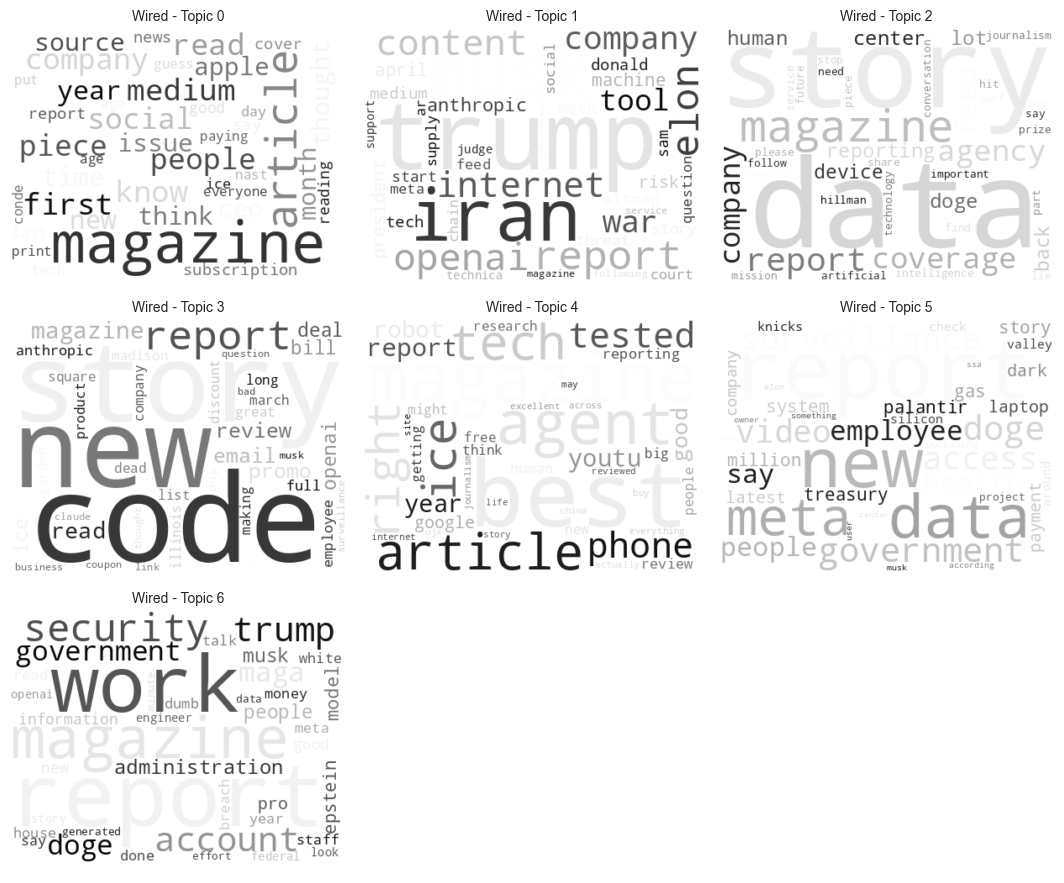

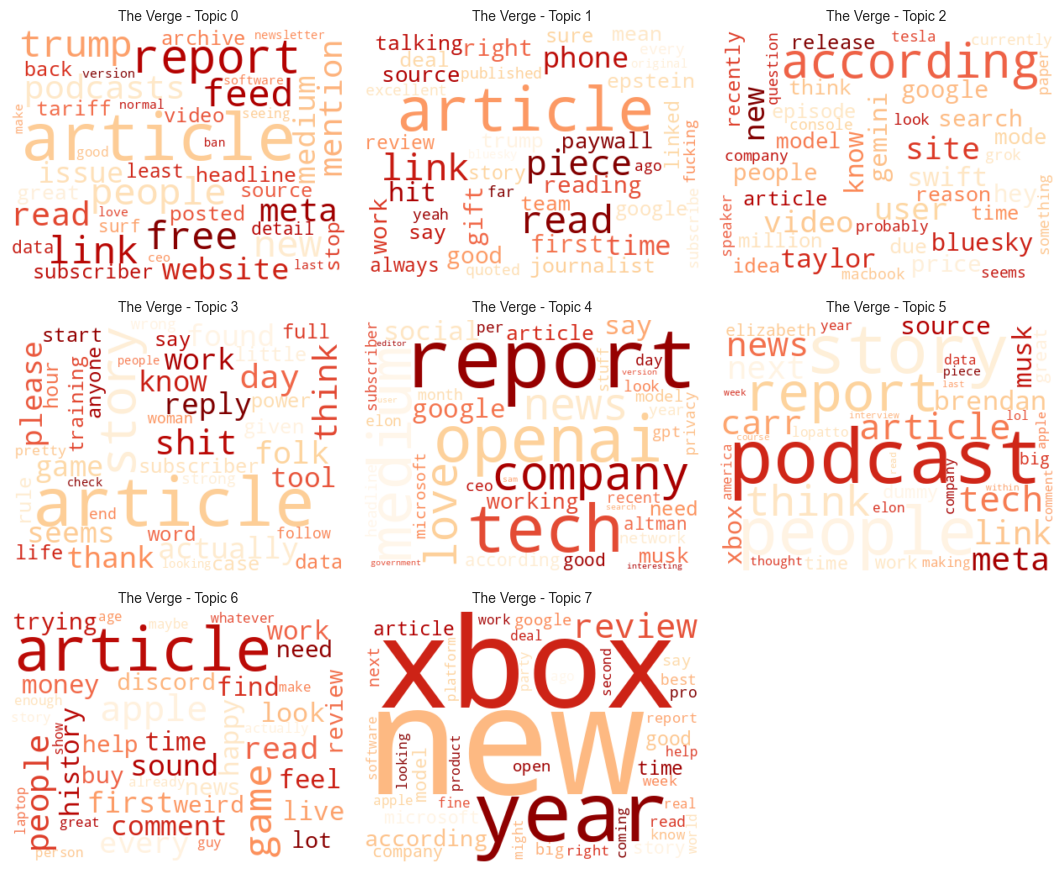

In [6]:
def plot_topic_clouds(lda_model, brand: str, fname: str) -> None:
    k = lda_model.num_topics
    cols = 3
    rows = int(np.ceil(k / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.6, rows * 3))
    axes = np.atleast_2d(axes).flatten()
    for tid in range(k):
        topic_words = dict(lda_model.show_topic(tid, topn=40))
        wc = WordCloud(width=400, height=300, background_color="white",
                       colormap="Greys" if brand == "Wired" else "OrRd")\
                .generate_from_frequencies(topic_words)
        axes[tid].imshow(wc, interpolation="bilinear")
        axes[tid].set_title(f"{brand} - Topic {tid}", fontsize=10)
        axes[tid].axis("off")
    for ax in axes[k:]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

plot_topic_clouds(wired_lda, "Wired",     "11_wired_topic_clouds.png")
plot_topic_clouds(verge_lda, "The Verge", "11_verge_topic_clouds.png")

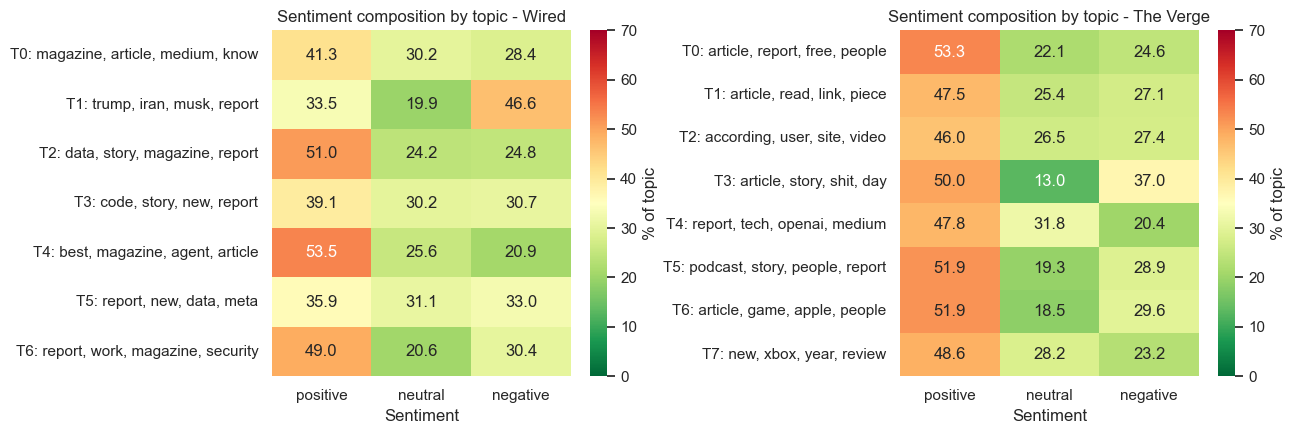

In [7]:
def assign_dominant_topic(lda_model, dictionary, df: pd.DataFrame) -> pd.DataFrame:
    topics = []
    for txt in df["text_clean_no_brand"]:
        if not txt:
            topics.append((-1, 0.0))
            continue
        bow = dictionary.doc2bow(txt.split())
        if not bow:
            topics.append((-1, 0.0))
            continue
        dist = lda_model.get_document_topics(bow, minimum_probability=0.0)
        top = max(dist, key=lambda x: x[1])
        topics.append((int(top[0]), float(top[1])))
    out = df.copy()
    out["topic_id"]   = [t[0] for t in topics]
    out["topic_prob"] = [t[1] for t in topics]
    return out

wired_posts_t = assign_dominant_topic(wired_lda, wired_dict, wired_posts)
verge_posts_t = assign_dominant_topic(verge_lda, verge_dict, verge_posts)

wired_posts_t.to_csv(PROC_DIR / "wired_posts_topics.csv", index=False)
verge_posts_t.to_csv(PROC_DIR / "verge_posts_topics.csv", index=False)

# Topic × sentiment heatmap, which topics drive positivity vs negativity?
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, df, brand, lda in [
    (axes[0], wired_posts_t, "Wired", wired_lda),
    (axes[1], verge_posts_t, "The Verge", verge_lda),
]:
    valid = df[df["topic_id"] >= 0].copy()
    pivot = (
        valid.groupby(["topic_id", "sentiment"]).size()
        .unstack(fill_value=0).reindex(columns=["positive", "neutral", "negative"], fill_value=0)
    )
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_pct.index = [f"T{tid}: {', '.join(w for w, _ in lda.show_topic(tid, topn=4))}"
                       for tid in pivot_pct.index]
    sns.heatmap(pivot_pct, annot=True, fmt=".1f", cmap="RdYlGn_r",
                cbar_kws={"label": "% of topic"}, ax=ax,
                vmin=0, vmax=70)
    ax.set_title(f"Sentiment composition by topic - {brand}")
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "12_topic_sentiment_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Wired co-occurrence graph: 59 nodes, 285 edges
Verge co-occurrence graph: 60 nodes, 239 edges


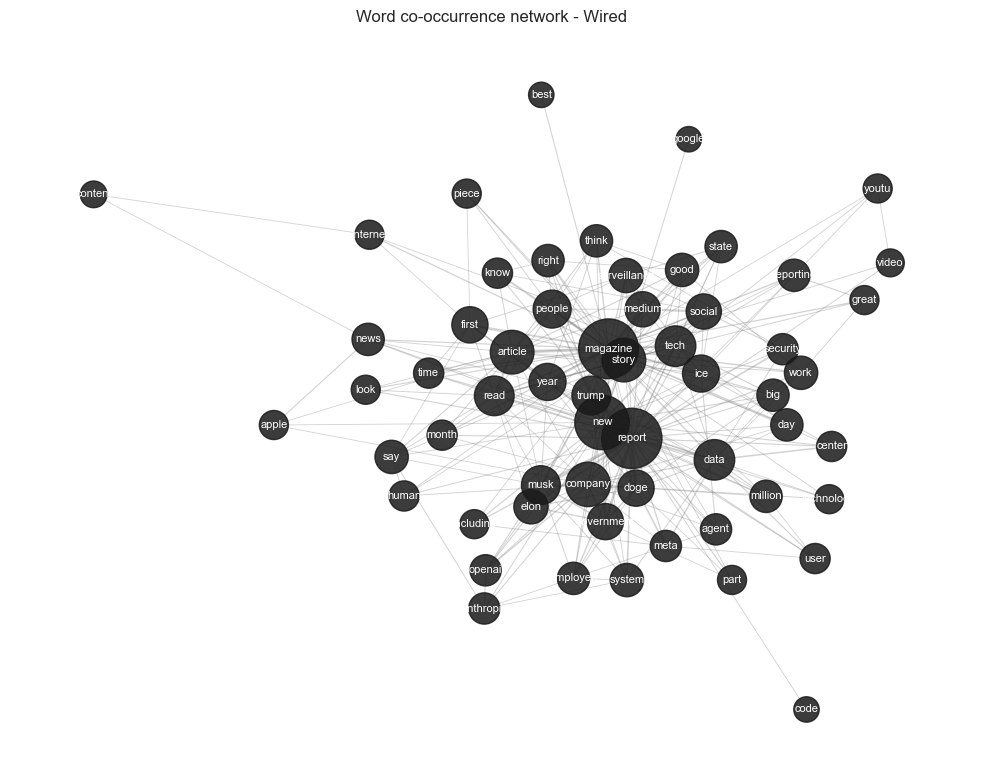

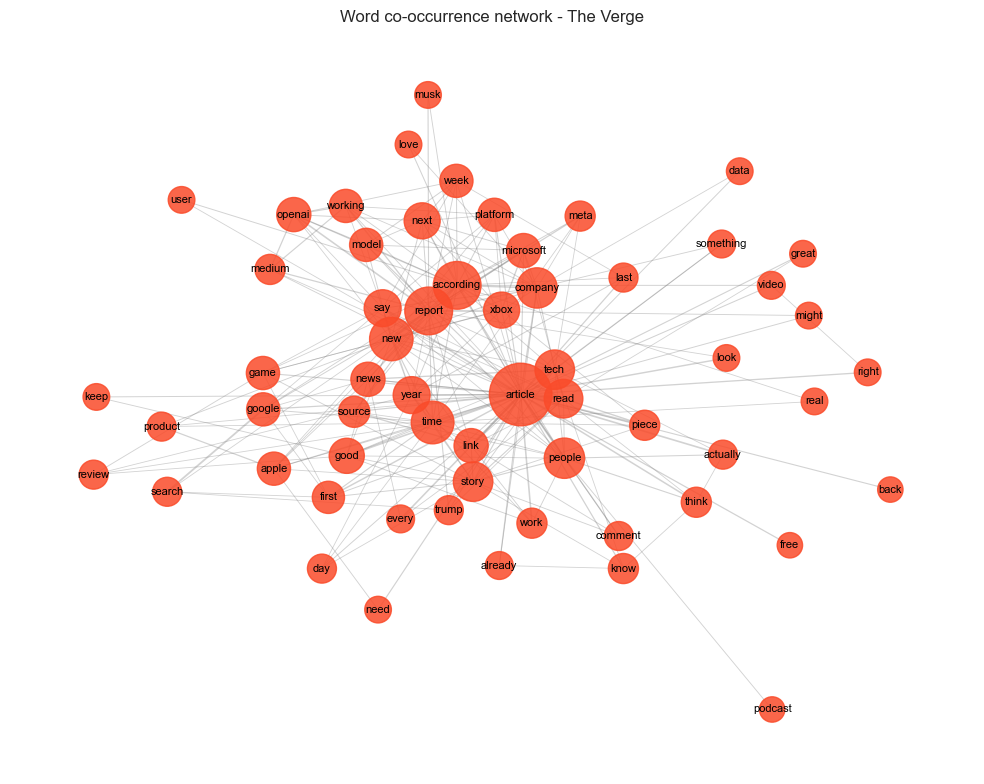


Top 10 most central tokens - Wired:
   token  degree_centrality  frequency
  report           0.793103        213
magazine           0.775862        310
     new           0.620690        123
 company           0.362069         79
   story           0.344828        103
 article           0.344828        107
    tech           0.275862         64
    data           0.275862         70
    read           0.258621         75
    musk           0.241379         51

Top 10 most central tokens - The Verge:
    token  degree_centrality  frequency
  article           0.864407        350
   report           0.440678         98
according           0.440678         95
      new           0.338983         69
     time           0.322034         56
   people           0.271186         65
  company           0.271186         55
     tech           0.254237         59
    story           0.254237         86
     read           0.237288         79

Saved data/processed/topics_summary.json


In [8]:
def cooccurrence_graph(df: pd.DataFrame, top_vocab: int = 60, min_edge_weight: int = 4) -> nx.Graph:
    """
    Build a per-brand co-occurrence graph: nodes are top-frequency tokens,
    edges weighted by the number of posts in which both tokens co-appear.
    """
    counter = Counter()
    for txt in df["text_clean_no_brand"]:
        counter.update(set(txt.split()))     # set() so each token counts once per post
    vocab = {tok for tok, _ in counter.most_common(top_vocab)}

    edge_weights = Counter()
    for txt in df["text_clean_no_brand"]:
        toks = sorted(set(txt.split()) & vocab)
        for a, b in combinations(toks, 2):
            edge_weights[(a, b)] += 1

    G = nx.Graph()
    for tok in vocab:
        G.add_node(tok, freq=counter[tok])
    for (a, b), w in edge_weights.items():
        if w >= min_edge_weight:
            G.add_edge(a, b, weight=w)
    G.remove_nodes_from([n for n in list(G.nodes) if G.degree(n) == 0])
    return G

def plot_cooccurrence(G: nx.Graph, brand: str, fname: str) -> pd.DataFrame:
    degree_centrality = nx.degree_centrality(G)
    sizes = [300 + 2000 * degree_centrality[n] for n in G.nodes]
    weights = [G[u][v]["weight"] for u, v in G.edges]
    pos = nx.spring_layout(G, seed=42, k=0.5, iterations=80)

    fig, ax = plt.subplots(figsize=(10, 8))
    nx.draw_networkx_edges(G, pos, width=[0.4 + 0.05 * w for w in weights],
                           alpha=0.35, edge_color="grey", ax=ax)
    nx.draw_networkx_nodes(G, pos, node_size=sizes,
                           node_color=BRAND_COLORS[brand], alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="white"
                            if brand == "Wired" else "black", ax=ax)
    ax.set_title(f"Word co-occurrence network - {brand}")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

    cdf = (pd.DataFrame({
        "token": list(degree_centrality.keys()),
        "degree_centrality": list(degree_centrality.values()),
        "frequency": [G.nodes[n]["freq"] for n in degree_centrality],
    }).sort_values("degree_centrality", ascending=False))
    return cdf

wired_G = cooccurrence_graph(wired_posts)
verge_G = cooccurrence_graph(verge_posts)

print(f"Wired co-occurrence graph: {wired_G.number_of_nodes()} nodes, {wired_G.number_of_edges()} edges")
print(f"Verge co-occurrence graph: {verge_G.number_of_nodes()} nodes, {verge_G.number_of_edges()} edges")

wired_centrality = plot_cooccurrence(wired_G, "Wired",     "13_wired_cooccurrence.png")
verge_centrality = plot_cooccurrence(verge_G, "The Verge", "13_verge_cooccurrence.png")

print("\nTop 10 most central tokens - Wired:")
print(wired_centrality.head(10).to_string(index=False))
print("\nTop 10 most central tokens - The Verge:")
print(verge_centrality.head(10).to_string(index=False))

wired_centrality.to_csv(TAB_DIR / "10_wired_cooccurrence_centrality.csv", index=False)
verge_centrality.to_csv(TAB_DIR / "10_verge_cooccurrence_centrality.csv", index=False)

# Summary JSON
topics_summary = {
    "k_selected": {"wired": int(best_k_wired), "verge": int(best_k_verge)},
    "coherence_scores": {
        "wired": {str(k): float(v) for k, v in wired_scores.items()},
        "verge": {str(k): float(v) for k, v in verge_scores.items()},
    },
    "topics": {
        "wired": [
            {"topic_id": tid, "top_terms": [w for w, _ in wired_lda.show_topic(tid, topn=10)]}
            for tid in range(wired_lda.num_topics)
        ],
        "verge": [
            {"topic_id": tid, "top_terms": [w for w, _ in verge_lda.show_topic(tid, topn=10)]}
            for tid in range(verge_lda.num_topics)
        ],
    },
    "top_distinctive_keywords": {
        "wired": [{"token": k, "wired_count": w, "verge_count": v} for k, w, v in distinctive_wired],
        "verge": [{"token": k, "verge_count": v, "wired_count": w} for k, v, w in distinctive_verge],
    },
    "co_occurrence_top_central": {
        "wired": wired_centrality.head(10).to_dict("records"),
        "verge": verge_centrality.head(10).to_dict("records"),
    },
    "method_notes": [
        "LDA fit on text_clean_no_brand (brand tokens removed so the topic captures the discourse, not the brand name).",
        "Vocabulary filtered to tokens appearing in >=5 posts and <=60% of posts.",
        "k chosen by maximising c_v coherence over k in {4,5,6,7,8}.",
        "Each post assigned its highest-probability topic via get_document_topics().",
        "Co-occurrence edges = number of posts in which both tokens appear together (top-60 vocab, edge weight >= 4).",
    ],
}
with open(PROC_DIR / "topics_summary.json", "w") as f:
    json.dump(topics_summary, f, indent=2, default=str)

print("\nSaved data/processed/topics_summary.json")